In [163]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [164]:
# Leitura do arquivo

caminho_arquivo = 'tratados_10x10det/proton/proton1E17_array'

df = pl.read_csv(caminho_arquivo, has_header= False).filter(pl.col('column_1').str.contains('TRIG'))

df = df.with_columns(pl.col("column_1").str.split(" ").alias("split_column"))
df = df.with_columns(pl.col("split_column").list.get(0).alias("TRIG"))
df = df.with_columns(pl.col("split_column").list.get(1).cast(pl.Int64).alias("positrons"))
df = df.with_columns(pl.col("split_column").list.get(2).cast(pl.Int64).alias("electrons"))
df = df.with_columns(pl.col("split_column").list.get(3).cast(pl.Int64).alias("muons_plus"))
df = df.with_columns(pl.col("split_column").list.get(4).cast(pl.Int64).alias("muons_minus"))
df = df.with_columns(
    (pl.col("positrons") + pl.col("electrons") + pl.col("muons_plus") + pl.col("muons_minus")).alias("total_particles")
)

df

column_1,split_column,TRIG,positrons,electrons,muons_plus,muons_minus,total_particles
str,list[str],str,i64,i64,i64,i64,i64
"""TRIG1 0 0 0 0""","[""TRIG1"", ""0"", … ""0""]","""TRIG1""",0,0,0,0,0
"""TRIG2 0 937 0 0""","[""TRIG2"", ""0"", … ""0""]","""TRIG2""",0,937,0,0,937
"""TRIG3 0 0 0 0""","[""TRIG3"", ""0"", … ""0""]","""TRIG3""",0,0,0,0,0
"""TRIG4 0 0 0 0""","[""TRIG4"", ""0"", … ""0""]","""TRIG4""",0,0,0,0,0
"""TRIG5 0 0 0 0""","[""TRIG5"", ""0"", … ""0""]","""TRIG5""",0,0,0,0,0
…,…,…,…,…,…,…,…
"""TRIG96 855 0 0 0""","[""TRIG96"", ""855"", … ""0""]","""TRIG96""",855,0,0,0,855
"""TRIG97 0 1080 0 0""","[""TRIG97"", ""0"", … ""0""]","""TRIG97""",0,1080,0,0,1080
"""TRIG98 0 0 0 0""","[""TRIG98"", ""0"", … ""0""]","""TRIG98""",0,0,0,0,0


In [165]:
import re
def formatar_string(s):

    nome_arquivo = s.split('/')[-1]
   
    match = re.match(r'([a-zA-Z]+)([0-9]+(?:\.[0-9]+)?[Ee][0-9]+)', nome_arquivo)

    if match:
        
        palavra = match.group(1).capitalize()
        numero = match.group(2)

        return f'{palavra} {numero}'
    else:
        return nome_arquivo

name = formatar_string(caminho_arquivo)
name

'Proton 1E17'

In [166]:
# Posição dos tanques

numDetectors = 100
gridSize = 10
spacing = 10
area = 1.0

x_det = np.zeros(numDetectors)
y_det = np.zeros(numDetectors)
areas = np.full(numDetectors, area)

index = 0
halfGridSize = gridSize // 2

for i in range(gridSize):
    for j in range(gridSize):
        x_det[index] = (j - halfGridSize + 0.5) * spacing
        y_det[index] = (i - halfGridSize + 0.5) * spacing
        areas[index] = area
        index += 1

#print("x_det:", x_det)
#print("y_det:", y_det)
#print("areas:", areas)

In [167]:
from scipy.spatial import KDTree

df2 = df.group_by('TRIG').agg(pl.col('total_particles')).sort(
    pl.col('TRIG').str.extract(r"TRIG([0-9]*)", 1).cast(int)
)

# Método KDTree 
positions = np.column_stack((x_det, y_det))
tree = KDTree(positions)
d_max = 15  # Distância máxima para considerar como próximos

# Validar simulações com triangulação
num_simulations = len(df2["total_particles"][0])

valid_simulations = []

for sim_idx in range(num_simulations):
    detections = np.array([df2["total_particles"][i][sim_idx] > 0 for i in range(100)])  

    detected_indices = np.where(detections)[0]
    if len(detected_indices) < 3:
        continue
    
    neighbors = []
    for tank in detected_indices:
        neighbors.append(set(tree.query_ball_point(positions[tank], d_max)))
    
    valid = False
    n = len(detected_indices)
    for i in range(n):
        tank_i = detected_indices[i]
        for j in range(i + 1, n):
            tank_j = detected_indices[j]
            if tank_j not in neighbors[i]:  
                continue
            for k in range(j + 1, n):
                tank_k = detected_indices[k]
                if tank_k in neighbors[i] and tank_k in neighbors[j]:
                    valid = True
                    break
            if valid:
                break
        if valid:
            break
    
    if valid:
        valid_simulations.append(sim_idx)


# Atualizar o dataframe
triangulation_particles = [
    [particles[i] for i in valid_simulations] for particles in df2["total_particles"]
]

triangulation_particles = df2.with_columns(
    pl.Series("triangulation_particles", triangulation_particles)
)

print(f"Simulações válidas: {len(valid_simulations)}")
triangulation_particles

Simulações válidas: 698


TRIG,total_particles,triangulation_particles
str,list[i64],list[i64]
"""TRIG1""","[0, 0, … 0]","[0, 0, … 0]"
"""TRIG2""","[937, 0, … 0]","[937, 0, … 0]"
"""TRIG3""","[0, 0, … 0]","[0, 0, … 0]"
"""TRIG4""","[0, 0, … 0]","[0, 0, … 0]"
"""TRIG5""","[0, 0, … 587]","[0, 0, … 587]"
…,…,…
"""TRIG96""","[699, 0, … 855]","[699, 0, … 855]"
"""TRIG97""","[0, 0, … 1080]","[0, 0, … 1080]"
"""TRIG98""","[0, 6, … 0]","[0, 6, … 0]"


In [168]:
triangulation_particles = triangulation_particles.with_columns(mean_particles = pl.col('triangulation_particles').list.mean())  
trigs = triangulation_particles['mean_particles'].to_list()
triangulation_particles

TRIG,total_particles,triangulation_particles,mean_particles
str,list[i64],list[i64],f64
"""TRIG1""","[0, 0, … 0]","[0, 0, … 0]",95.007163
"""TRIG2""","[937, 0, … 0]","[937, 0, … 0]",131.359599
"""TRIG3""","[0, 0, … 0]","[0, 0, … 0]",162.544413
"""TRIG4""","[0, 0, … 0]","[0, 0, … 0]",221.5
"""TRIG5""","[0, 0, … 587]","[0, 0, … 587]",218.528653
…,…,…,…
"""TRIG96""","[699, 0, … 855]","[699, 0, … 855]",254.379656
"""TRIG97""","[0, 0, … 1080]","[0, 0, … 1080]",205.520057
"""TRIG98""","[0, 6, … 0]","[0, 6, … 0]",175.722063


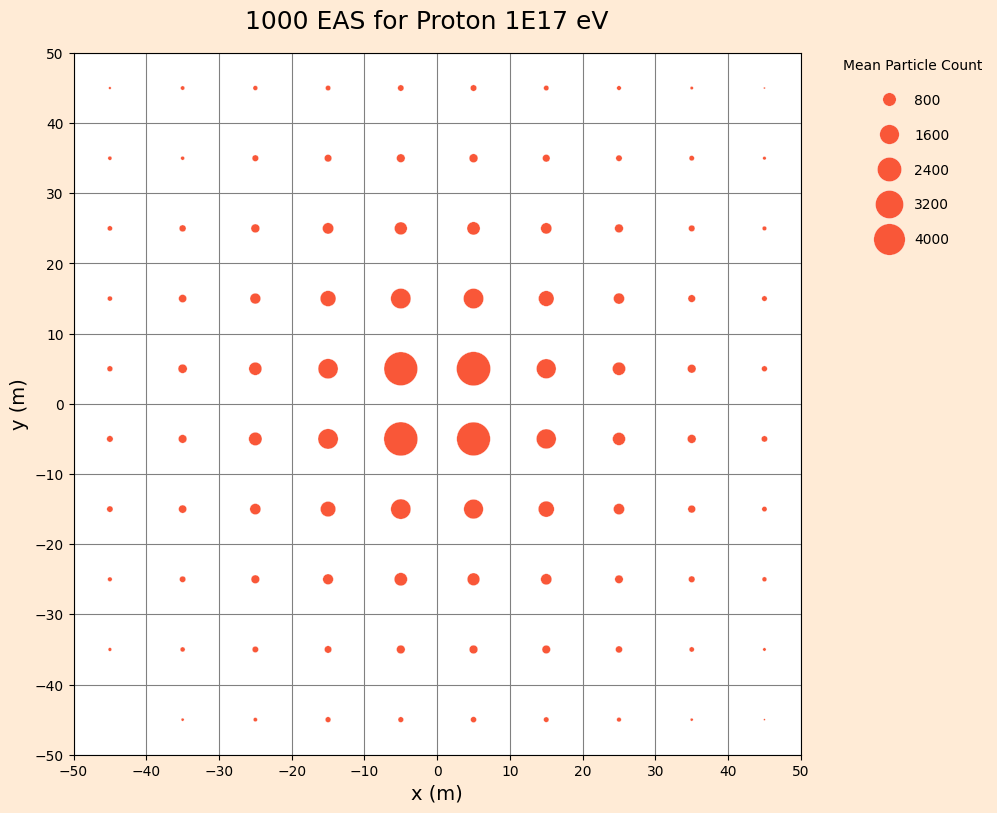

In [169]:
# Plot de partículas por tanque
fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle('1000 EAS for ' + str(name) + ' eV', size = 18)
fig.tight_layout()
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='-')
ax.xaxis.grid(color='gray', linestyle='-')

scatter = sns.scatterplot(x = x_det, y = y_det, ax = ax, color = '#F95738', size=trigs, sizes=(0, 600), legend = 'brief')
handles, labels = scatter.get_legend_handles_labels()
for handle in handles:
    handle.set_color('#F95738')
ax.legend(handles=handles, labels=labels, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.,
           frameon=False, title='Mean Particle Count', labelspacing = 1.5)

plt.xticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
plt.yticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
ax.set_xlabel('x (m)', size = 14)
ax.set_ylabel('y (m)', size = 14)


plt.savefig('plots/' + name.split(' ')[0].lower() + '/counts_' + caminho_arquivo.split('/')[-1].split('_')[0] + '.png', bbox_inches = 'tight', dpi = 300)

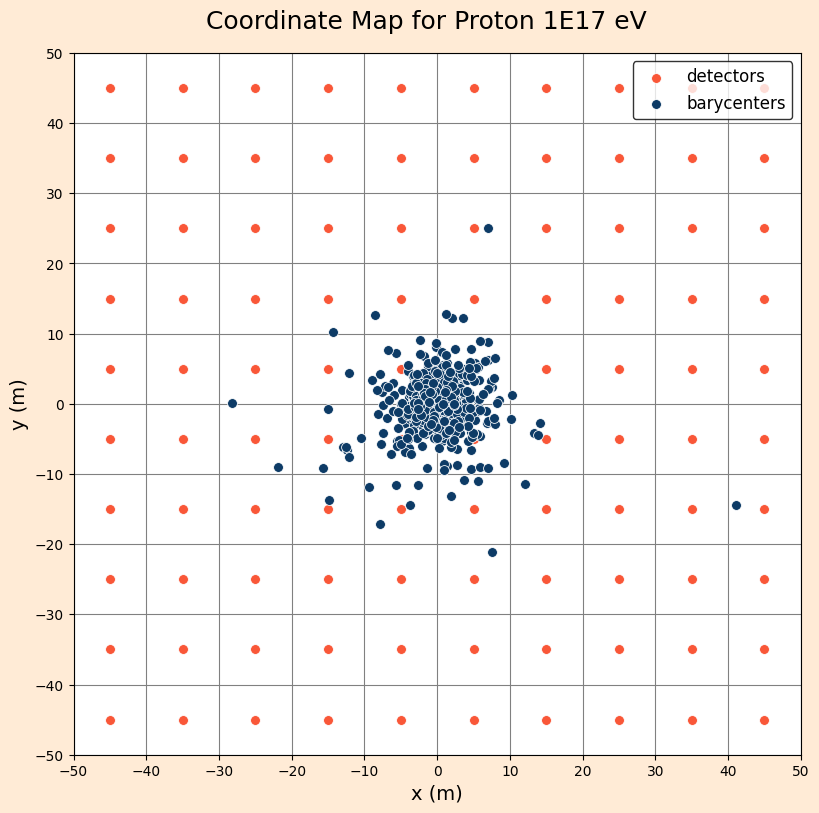

In [170]:
# Posição dos baricentros
x_b = [0] * len(valid_simulations)
y_b = [0] * len(valid_simulations)
rho = []

for i in range(len(valid_simulations)):
        numerator = 0
        numerator1 = 0
        denominator = 0
        for j in range(len(trigs)):
                numerator += (triangulation_particles['triangulation_particles'][j][i]*x_det[j])
                numerator1 += (triangulation_particles['triangulation_particles'][j][i]*y_det[j])
                denominator += (triangulation_particles['triangulation_particles'][j][i])
                rho.append((triangulation_particles['triangulation_particles'][j][i])/1)
                if denominator != 0: 
                    x_b[i] = numerator / denominator
                    y_b[i] = numerator1 / denominator
                else:
                    x_b[i] = 0 
                    y_b[i] = 0 

fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle('Coordinate Map for ' + str(name) + ' eV', size = 18)
fig.tight_layout()
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='-')
ax.xaxis.grid(color='gray', linestyle='-')

sns.scatterplot(x = x_det, y = y_det, ax = ax, color = '#F95738', s = 50)
sns.scatterplot(x = x_b, y = y_b, ax = ax, color = '#0D3B66',s = 50)

plt.xticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
plt.yticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
ax.set_xlabel('x (m)', size = 14)
ax.set_ylabel('y (m)', size = 14)


ax.legend(['detectors', 'barycenters'], edgecolor = 'black', fontsize = 12, loc = 1)

plt.savefig('plots/' + name.split(' ')[0].lower() + '/map_' + caminho_arquivo.split('/')[-1].split('_')[0] + '.png',bbox_inches = 'tight', dpi = 300)

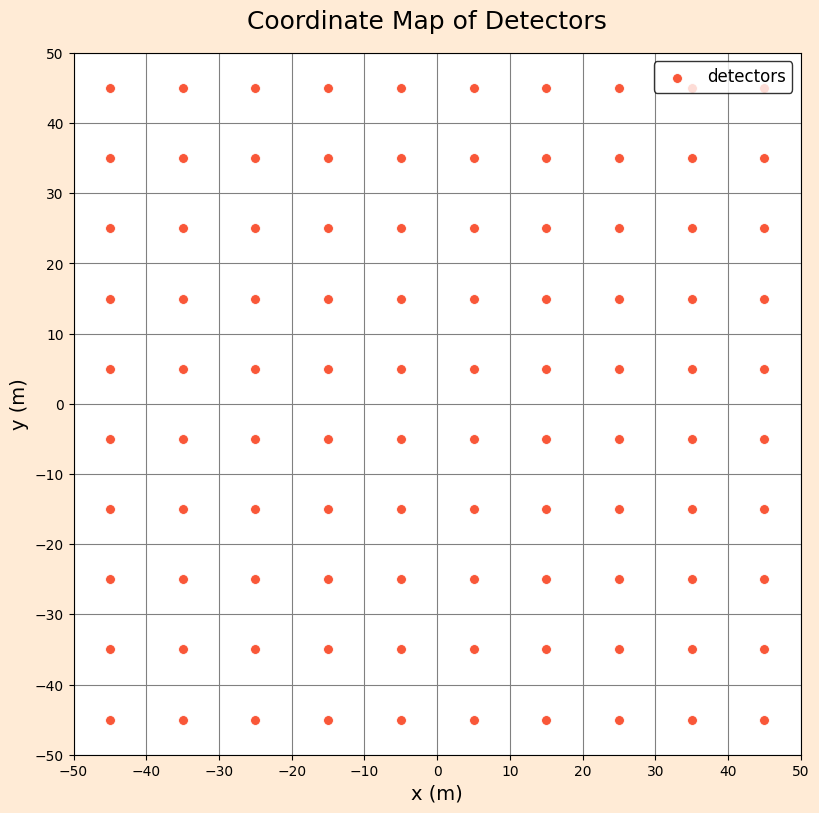

In [171]:
fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle('Coordinate Map of Detectors', size = 18)
fig.tight_layout()
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='-')
ax.xaxis.grid(color='gray', linestyle='-')

sns.scatterplot(x = x_det, y = y_det, ax = ax, color = '#F95738', s = 50)

plt.xticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
plt.yticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
ax.set_xlabel('x (m)', size = 14)
ax.set_ylabel('y (m)', size = 14)


ax.legend(['detectors'], edgecolor = 'black', fontsize = 12, loc = 1)

In [172]:
i = 4
eas = 1000
area_detectores = 100
area_total = (np.pi*100**2)
total_particles = [2.120729e+07, 3.061755e+07, 4.2374e+08, 1.56078e+09, 5.81296e+09]
part = total_particles[i]/eas * (area_detectores/area_total)
part

18503.226359909277

[1.07580975e+07 4.28601361e+00]
[1.67091502 2.72361043 3.29750257 3.55184489 4.16798474]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_11016\1664240466.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


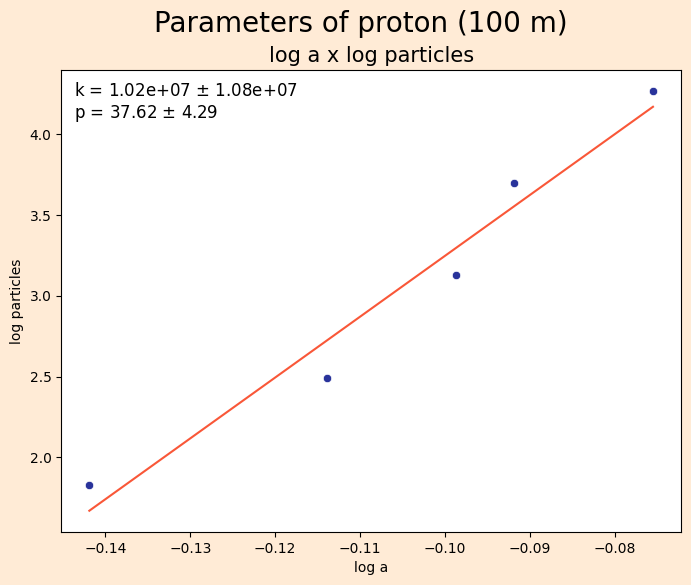

In [173]:
from scipy.optimize import curve_fit

# Fit do próton

a = [0.7213, 0.7693, 0.7968, 0.8093, 0.8404]
particles = [67.50490066166643, 308.41357138375065, 1348.8063117151946, 4968.117041579368, 18503.226359909277]

E = [1E15, 3.16E15, 1E16, 3.16E16, 1E17]

loga = np.log10(a)
logparticles = np.log10(particles)
#logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of proton (100 m)', size = 20)
#fig.tight_layout()


ax.set_title('log a x log particles', size = 15)
ax.set_xlabel('log a')
ax.set_ylabel('log particles')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_proton, cov = curve_fit(power, a, np.log10(particles), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(a,*coefficients_proton))

ax.plot(loga, power(a,*coefficients_proton), color = '#F95738')
sns.scatterplot(x = loga, y = logparticles, color = '#29339B', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_proton[0],inc[0],coefficients_proton[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)

In [174]:
r_b = [] 

# Estruturação da lista rho para 100 tanques
rho_reshaped = np.array(rho).reshape(len(x_b), 100)


for i in range(len(valid_simulations)):
    #aux = ((x_det[i]-x_b[i])**2 + (y_det[i]-y_b[i])**2)**0.5
    aux = x_b[i]** 2 + y_b[i]**2
    r_b.append(aux)

data = {
    'x_b':x_b,
    'y_b':y_b,
    'r_b':r_b
}

for i in range(100):
    data[f'rho_{i+1}'] = rho_reshaped[:, i].tolist()

df = pl.DataFrame(data, strict=False)

rho_cols = [pl.col(f'rho_{i+1}') for i in range(100)]

df = df.with_columns(
    rho_total=pl.sum_horizontal(rho_cols)        
)

df = df.with_columns(
    particles_total=pl.col('rho_total') * 1
)

df = df.with_columns(
    a=(pl.col("particles_total") / coefficients_proton[0]).pow(1 / coefficients_proton[1])
)

distance_bary = []
for i in range(100):
    x = x_det[i]
    y = y_det[i]
    expr = ((pl.col("x_b") - x)**2 + (pl.col("y_b") - y)**2).sqrt().alias(f"r{i+1}_b")
    distance_bary.append(expr)

df = df.with_columns(distance_bary)

# Reordenar colunas
df = df.select([
    'x_b', 
    'y_b', 
    'r_b', 
    'rho_total', 
    'particles_total', 
    'a',
    *[f'r{i+1}_b' for i in range(100)],
    *[f'rho_{i+1}' for i in range(100)]
])

df

x_b,y_b,r_b,rho_total,particles_total,a,r1_b,r2_b,r3_b,r4_b,r5_b,r6_b,r7_b,r8_b,r9_b,r10_b,r11_b,r12_b,r13_b,r14_b,r15_b,r16_b,r17_b,r18_b,r19_b,r20_b,r21_b,r22_b,r23_b,r24_b,r25_b,r26_b,r27_b,r28_b,r29_b,r30_b,r31_b,…,rho_64,rho_65,rho_66,rho_67,rho_68,rho_69,rho_70,rho_71,rho_72,rho_73,rho_74,rho_75,rho_76,rho_77,rho_78,rho_79,rho_80,rho_81,rho_82,rho_83,rho_84,rho_85,rho_86,rho_87,rho_88,rho_89,rho_90,rho_91,rho_92,rho_93,rho_94,rho_95,rho_96,rho_97,rho_98,rho_99,rho_100
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
-1.797405,-3.637079,16.459005,20346.0,20346.0,0.847657,59.810998,53.040584,47.426276,43.418887,41.486719,41.917729,44.643522,49.284807,55.361903,62.457092,53.3863,45.673243,39.012732,34.028537,31.526012,32.091082,35.577882,41.252076,48.34958,56.33498,48.195836,39.481473,31.539417,25.113401,21.601644,22.418277,27.175857,34.270619,42.549071,51.442896,44.671917,…,0.0,0.0,0.0,626.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,873.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1367.0,0.0,0.0,0.0,626.0,0.0,0.0,0.0,699.0,0.0,0.0,0.0,0.0
3.251866,3.690104,24.191497,16612.0,16612.0,0.843101,68.549025,61.918749,56.292931,51.998623,49.384405,48.721475,50.087372,53.326424,58.12633,64.137609,61.847932,54.407071,47.907119,42.779139,39.560301,38.729576,40.434425,44.383617,50.048657,56.919512,56.137017,47.815555,40.265245,34.003715,29.85323,28.743312,31.002269,36.001436,42.790958,50.655984,51.745169,…,573.0,538.0,1925.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,488.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,334.0,0.0,730.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,569.0,0.0,0.0,6.0,0.0,0.0
4.605558,-9.289556,107.50702,4462.0,4462.0,0.814153,61.122395,53.327629,46.386688,40.738357,36.979758,35.712622,37.192475,41.123826,46.894114,53.916108,55.872518,47.218928,39.211172,32.332721,27.446196,25.713469,27.732136,32.817071,39.810162,47.882542,52.033926,42.607725,33.515774,25.123613,18.414255,15.715395,18.837794,25.743957,34.214619,43.342,49.933161,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,420.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,492.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5.165237,-2.310158,32.016504,11075.0,11075.0,0.834065,65.870886,58.614579,52.272021,47.212916,43.883421,42.690162,43.808049,47.072714,52.082009,58.38862,59.876346,51.786794,44.481089,38.409147,34.233869,32.69026,34.137199,38.236679,44.257642,51.530904,55.057969,46.131065,37.746132,30.355654,24.862843,22.690444,24.729567,30.137132,37.482556,45.843618,51.745368,…,410.0,0.0,0.0,787.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,29.0,919.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
-4.599458,-2.864779,29.361974,13282.0,13282.0,0.838103,58.374486,51.957384,46.814089,43.399863,42.137124,43.214886,46.470588,51.492764,57.822953,65.080589,51.622439,44.236471,38.063822,33.776378,32.137717,33.538366,37.640552,43.689819,50.997936,59.099735,46.067036,37.605331,30.102327,24.456886,22.138844,24.127113,29.565296,36.960735,45.366122,54.314586,42.183734,…,345.0,0.0,0.0,0.0,0.0,126.0,0.0,0.0,0.0,0.0,0.0,0.0,903.0,628.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,525.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.012914,4.346285,18.890359,97183.0,97183.0,0.88363,66.792352,60.505867,55.323609,51.579486,49.600253,49.59765,51.571975,55.311936,60.490925,66.774949,59.785387,52.669102,46.623771,42.113154,39.664335,39.661079,42.103953,46.60992,52.651936,59.765944,53.734224,45.684883,38.559698,32.963495,29.771358,29.76702,32.95174,38.542949,45.665092,53.71259,48.994297,…,0.0,4312.0,2588.0,473.0,0.0,504.0,0.0,0.0,0.0,1473.0,749.0,1961.0,620.0,446.0,507.0,443.0,0.0,0.0,1096.0,689.

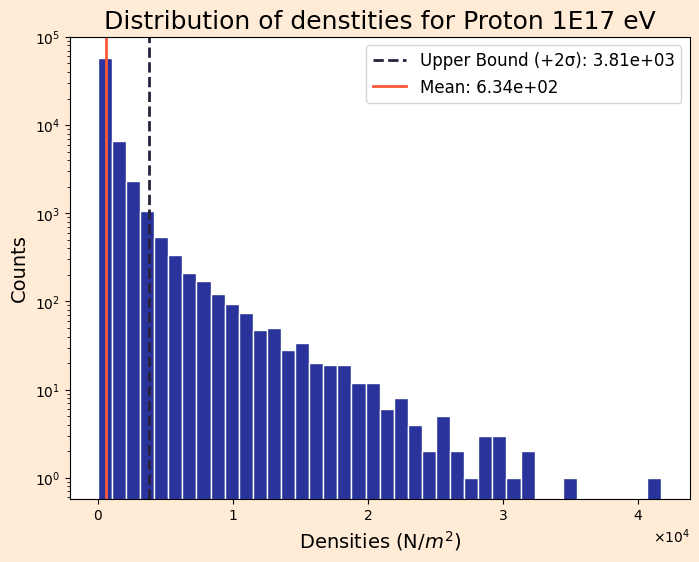

In [175]:

rho_columns = [f"rho_{i+1}" for i in range(100)] 
values = df.select(rho_columns).to_numpy().flatten()  

fig, ax = plt.subplots(figsize=(8, 6), facecolor='#FFEBD6')
plt.hist(values, color='#29339B', bins=40, edgecolor='white')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0), useMathText=True)
ax.set_yscale('log')


plt.title('Distribution of denstities for ' + str(name) + ' eV', size=18)  

# Calcula a média e o desvio padrão dos dados
mean = values.mean()
std = values.std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std


# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2e}')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2e}')

# Personaliza o eixo e a legenda
ax.set_xlabel('Densities (N/$m^2$)', size=14)
ax.set_ylabel('Counts', size=14)
ax.legend(loc='upper right', fontsize=12)

plt.savefig('plots/' + name.split(' ')[0].lower() + '/densities_' + caminho_arquivo.split('/')[-1] + '_array.png', bbox_inches = 'tight')


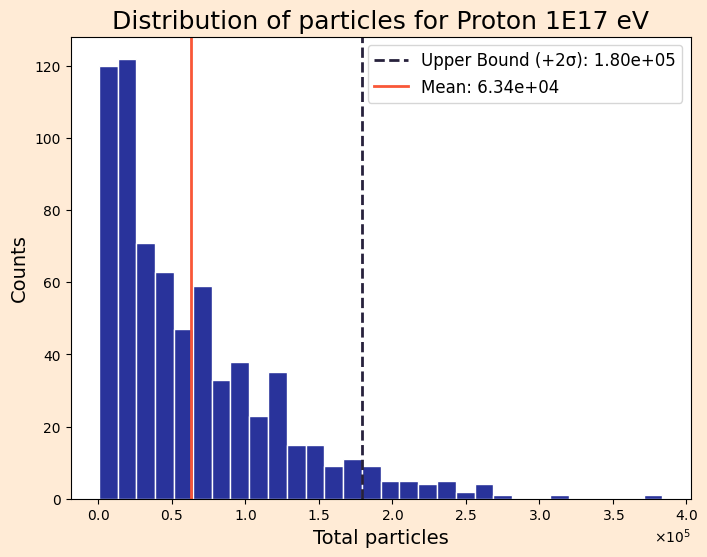

In [176]:
values = df.select('particles_total').to_numpy().flatten()  

fig, ax = plt.subplots(figsize=(8, 6), facecolor='#FFEBD6')
plt.hist(values, color='#29339B', bins=30, edgecolor='white')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0), useMathText=True)


plt.title('Distribution of particles for ' + str(name) + ' eV', size=18)  

# Calcula a média e o desvio padrão dos dados
mean = values.mean()
std = values.std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std


# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2e}')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2e}')

# Personaliza o eixo e a legenda
ax.set_xlabel('Total particles', size=14)
ax.set_ylabel('Counts', size=14)
ax.legend(loc='upper right', fontsize=12)

#plt.savefig('plots/' + name.split(' ')[0].lower() + '/densities_' + caminho_arquivo.split('/')[-1] + '_array.png', bbox_inches = 'tight')


In [177]:
# Modelagem NKG
def model(r, C, a, b):
    r0 = 78
    return C/(r0**2)*(r/r0)**(-a)*(1+r/r0)**(-b)


parameters = []
uncertainties = []
r_squared_list = []
rmse_list = []

x_cols = [f"r{i+1}_b" for i in range(100)]  
y_cols = [f"rho_{i+1}" for i in range(100)] 

x = df.select(x_cols).to_numpy()
y = df.select(y_cols).to_numpy()

a_std = df['a'].std()

#for i in range(len(x)):
#    print(f"Linha {i}: x = {x[i]}, y = {y[i]}")

for i in range(len(x)):
    r = x[i].flatten()
    r = np.where(r <= 0, 1e-9, r)  
    rho = y[i].flatten()
    a_fixed = df['a'][i]

    try:
        
        def current_model(r, C, b):
            return model(r, C, a_fixed, b)
        
        popt, pcov = curve_fit(current_model, r, rho, p0= [1E5, 3] , bounds= ([0, 2.5], [np.inf, 4.0]))
        perr = np.sqrt(np.diag(pcov))

        # Cálculo das métricas
        y_pred = current_model(r, *popt)

        # R²
        ss_res = np.sum((rho - y_pred)**2)
        ss_tot = np.sum((rho - np.mean(rho))**2)
        r_sq = 1 - (ss_res/ss_tot) if ss_tot != 0 else np.nan

        # RMSE
        rmse = np.sqrt(np.mean((rho - y_pred)**2))

        parameters.append([popt[0], a_fixed, popt[1]])
        uncertainties.append([perr[0], a_std, perr[1]])
        #parameters.append(popt)
        #uncertainties.append(perr)
        r_squared_list.append(r_sq)
        rmse_list.append(rmse)
    except RuntimeError:
        parameters.append([np.nan, np.nan])
        uncertainties.append([np.nan, np.nan])
        r_squared_list.append(np.nan)
        rmse_list.append(np.nan)


# Cria DataFrame com todos os parâmetros
parameters_df = pl.DataFrame({
    'C': [p[0] for p in parameters],
    'a': [p[1] for p in parameters],
    'b': [p[2] for p in parameters],
    'C_err': [e[0] for e in uncertainties],
    'a_err': [e[1] for e in uncertainties],
    'b_err': [e[2] for e in uncertainties],
    'R_2': r_squared_list,
    'RMSE': rmse_list
})

# Filtra valores válidos para estatísticas
valid = parameters_df.filter(
    pl.all_horizontal(
        pl.col('C').is_not_nan(),
        pl.col('a').is_not_nan(),
        pl.col('b').is_not_nan()
    )
)
print(parameters_df)

print("\nEstatísticas dos parâmetros:")
print(f"C: Média = {valid['C'].mean():.2e} ± {valid['C'].std():.2e}")
print(f"a: Média = {valid['a'].mean():.2f} ± {valid['a'].std():.2f}")
print(f"b: Média = {valid['b'].mean():.2f} ± {valid['b'].std():.2f}")
print(f"R² Médio = {valid['R_2'].mean():.3f} ± {valid['R_2'].std():.3f}")
print(f"RMSE Médio = {valid['RMSE'].mean():.3e} ± {valid['RMSE'].std():.3e}")

shape: (698, 8)
┌───────────────┬──────────┬──────────┬──────────────┬──────────┬──────────┬──────────┬────────────┐
│ C             ┆ a        ┆ b        ┆ C_err        ┆ a_err    ┆ b_err    ┆ R_2      ┆ RMSE       │
│ ---           ┆ ---      ┆ ---      ┆ ---          ┆ ---      ┆ ---      ┆ ---      ┆ ---        │
│ f64           ┆ f64      ┆ f64      ┆ f64          ┆ f64      ┆ f64      ┆ f64      ┆ f64        │
╞═══════════════╪══════════╪══════════╪══════════════╪══════════╪══════════╪══════════╪════════════╡
│ 1.1998e6      ┆ 0.847657 ┆ 2.762057 ┆ 163640.96460 ┆ 0.024922 ┆ 0.877644 ┆ 0.454975 ┆ 314.370678 │
│               ┆          ┆          ┆ 9            ┆          ┆          ┆          ┆            │
│ 650128.18314  ┆ 0.843101 ┆ 2.5      ┆ 126448.73390 ┆ 0.024922 ┆ 1.503681 ┆ 0.198138 ┆ 365.820561 │
│               ┆          ┆          ┆ 4            ┆          ┆          ┆          ┆            │
│ 206454.633665 ┆ 0.814153 ┆ 2.5      ┆ 94850.803548 ┆ 0.024922 ┆ 2.582973 

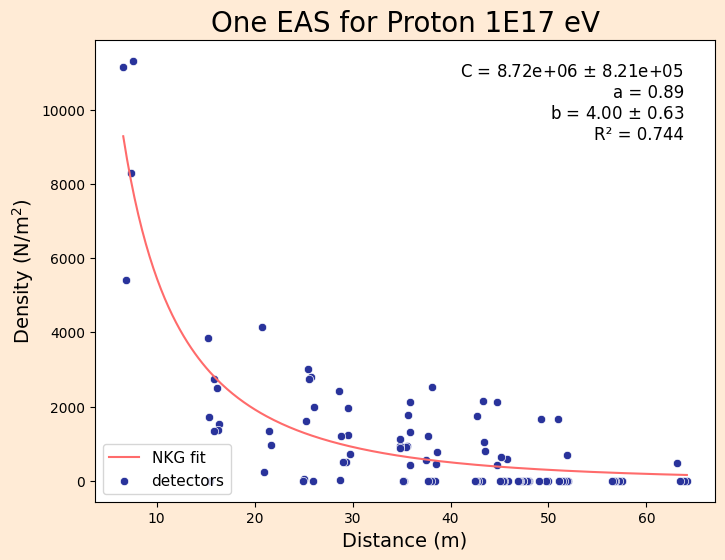

In [178]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.title('One EAS for ' + str(name) + ' eV', size = 20)
#fig.tight_layout()


#ax.set_title('log C x log E', size = 15)
ax.set_xlabel('Distance (m)', size = 14)
ax.set_ylabel('Density (N/m$^2$)', size = 14)
ax.set_facecolor('white')

i = 200

C = parameters_df['C'][i]
a = parameters_df['a'][i]
b = parameters_df['b'][i]
C_err = parameters_df['C_err'][i]
b_err = parameters_df['b_err'][i]

r_smooth = np.linspace(min(x[i]), max(x[i]), 300)
rho_fit = model(r_smooth, C, a, b)

sns.lineplot(x=r_smooth, y=rho_fit, color='#FF6B6B', ax=ax, label='NKG fit')

sns.scatterplot(x = x[i], y = y[i], color = '#29339B', ax = ax, label = 'detectors')

textstr = f'C = {C:.2e} $\pm$ {C_err:.2e}\na = {a:.2f}\nb = {b:.2f} $\pm$ {b_err:.2f}\nR² = {parameters_df["R_2"][i]:.3f}'

ax.text(0.95, 0.95, textstr, transform=ax.transAxes,
        verticalalignment='top', horizontalalignment='right',
        fontsize = 12
        )

ax.legend(
    loc='lower left',
    fontsize=11,
    frameon=True,
    facecolor='white',
)

plt.show()

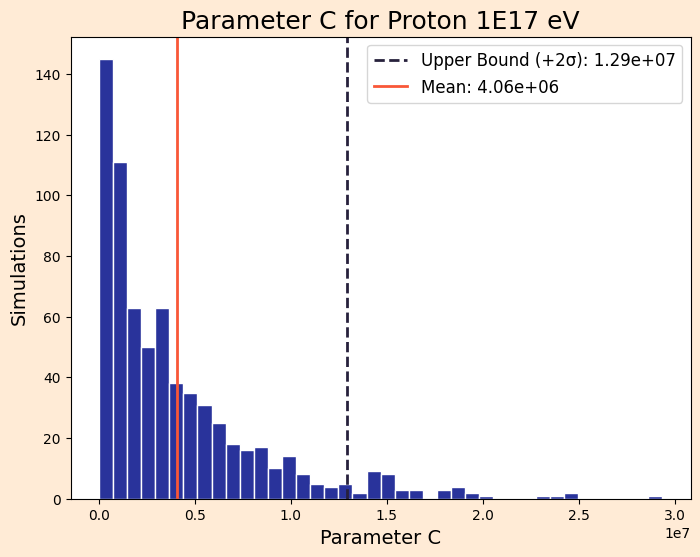

In [179]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.hist(parameters_df['C'], color='#29339B', bins= 40, edgecolor = 'white')
plt.ylabel('Simulations')
plt.xlabel('C')
plt.title('Parameter C for ' + str(name) + ' eV', size = 18)
#plt.grid(True)

# Calcula a média e o desvio padrão dos dados
mean = parameters_df['C'].mean()
std = parameters_df['C'].std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std


# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2e}')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2e}')

# Personaliza o eixo e a legenda
ax.set_xlabel('Parameter C', size=14)
ax.set_ylabel('Simulations', size=14)
ax.legend(loc='upper right', fontsize=12)

plt.savefig('plots/' + name.split(' ')[0].lower() + '/par_c_' + caminho_arquivo.split('/')[-1] + '_array.png', bbox_inches = 'tight')

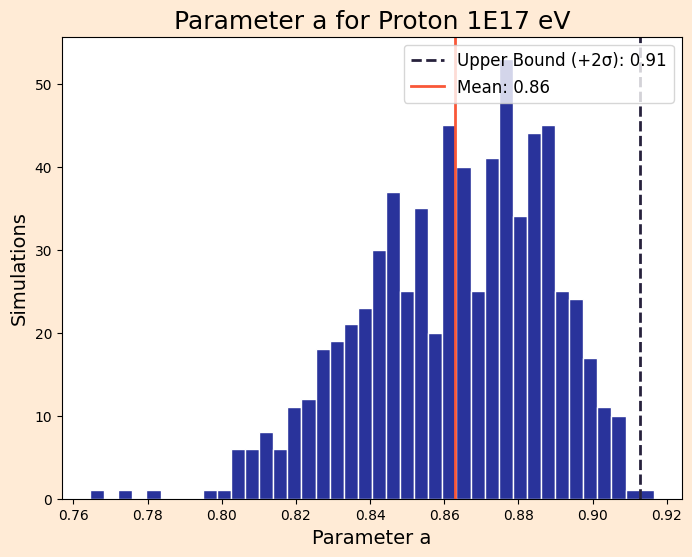

In [180]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.hist(parameters_df['a'], color='#29339B', bins= 40, edgecolor = 'white')
plt.ylabel('Simulations')
plt.xlabel('a')
plt.title('Parameter a for ' + str(name) + ' eV', size = 18)
#plt.grid(True)

# Calcula a média e o desvio padrão dos dados
mean = parameters_df['a'].mean()
std = parameters_df['a'].std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std


# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2f}')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2f}')

# Personaliza o eixo e a legenda
ax.set_xlabel('Parameter a', size=14)
ax.set_ylabel('Simulations', size=14)
ax.legend(loc='upper right', fontsize=12)

plt.savefig('plots/' + name.split(' ')[0].lower() + '/par_a_' + caminho_arquivo.split('/')[-1] + '_array.png', bbox_inches = 'tight')

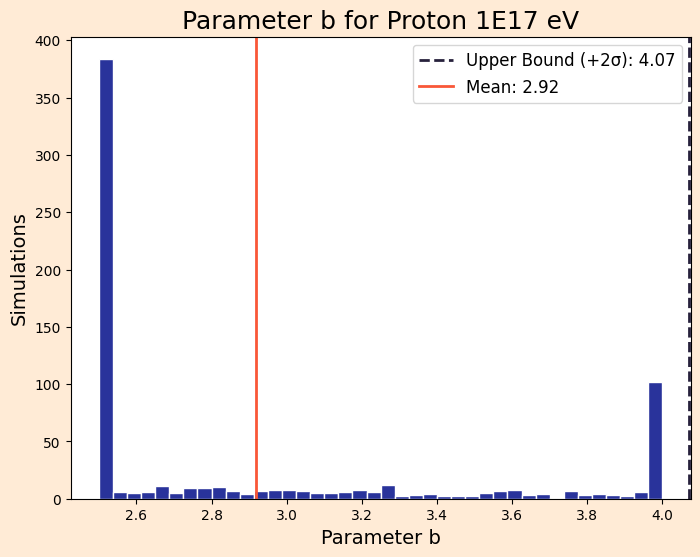

In [181]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.hist(parameters_df['b'], color='#29339B', bins= 40, edgecolor = 'white')
plt.ylabel('Simulations')
plt.xlabel('a')
plt.title('Parameter b for ' + str(name) + ' eV', size = 18)
#plt.grid(True)

# Calcula a média e o desvio padrão dos dados
mean = parameters_df['b'].mean()
std = parameters_df['b'].std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std


# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2f}')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2f}')

# Personaliza o eixo e a legenda
ax.set_xlabel('Parameter b', size=14)
ax.set_ylabel('Simulations', size=14)
ax.legend(loc='upper right', fontsize=12)

plt.savefig('plots/' + name.split(' ')[0].lower() + '/par_b_' + caminho_arquivo.split('/')[-1] + '_array.png', bbox_inches = 'tight')

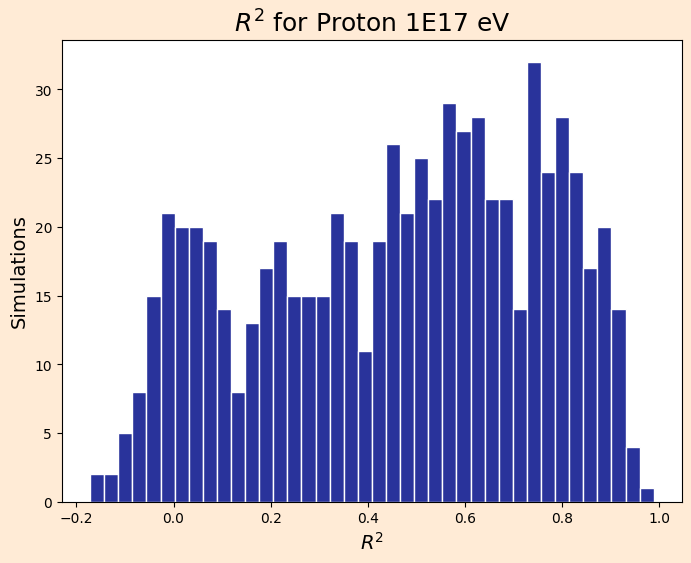

In [182]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.hist(parameters_df['R_2'], color='#29339B', bins= 40, edgecolor = 'white')
plt.ylabel('Simulations')
plt.xlabel('$R^2$')
plt.title('$R^2$ for ' + str(name) + ' eV', size = 18)
#plt.grid(True)

ax.set_xlabel('$R^2$', size=14)
ax.set_ylabel('Simulations', size=14)

plt.savefig('plots/' + name.split(' ')[0].lower() + '/rsquared_' + caminho_arquivo.split('/')[-1] + '_array.png', bbox_inches = 'tight')

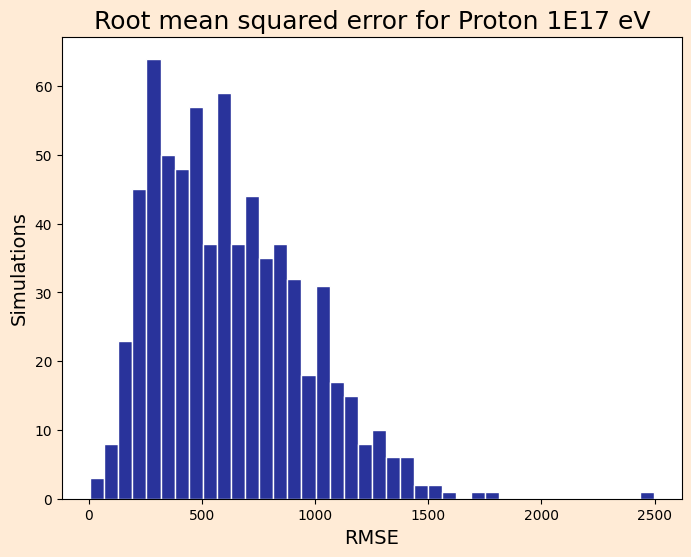

In [183]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.hist(parameters_df['RMSE'], color='#29339B', bins= 40, edgecolor = 'white')
plt.ylabel('Simulations')
plt.xlabel('RMSE')
plt.title('Root mean squared error for ' + str(name) + ' eV', size = 18)
#plt.grid(True)

ax.set_xlabel('RMSE', size=14)
ax.set_ylabel('Simulations', size=14)

plt.savefig('plots/' + name.split(' ')[0].lower() + '/rmse_' + caminho_arquivo.split('/')[-1] + '_array.png', bbox_inches = 'tight')

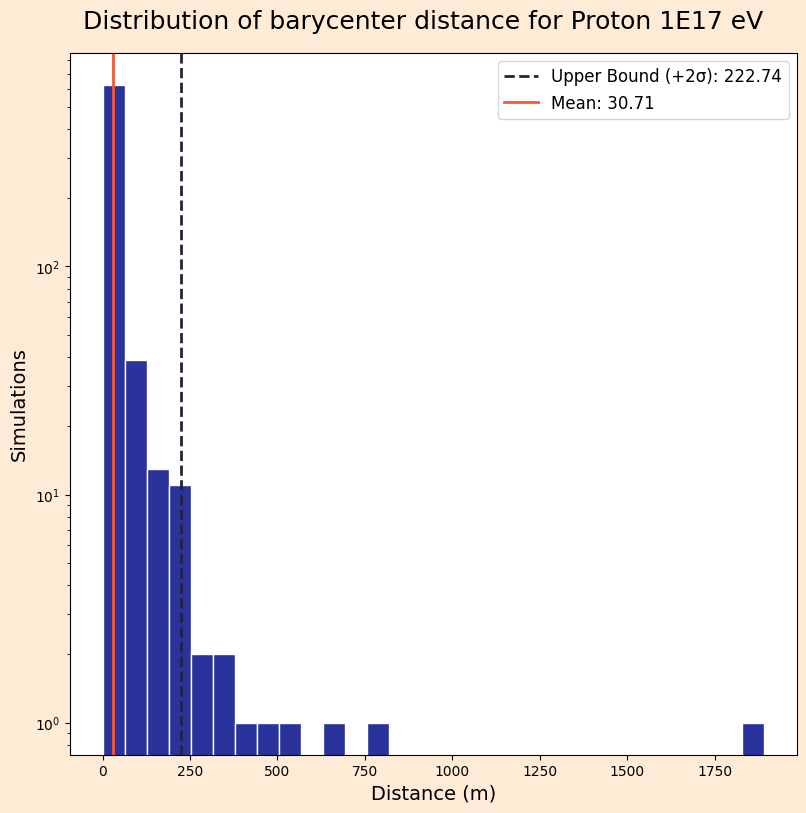

In [184]:
fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle('Distribution of barycenter distance for ' + str(name) + ' eV', size = 18)
fig.tight_layout()
ax.set_yscale('log')

# Calcula a média e o desvio padrão dos dados
mean = df['r_b'].mean()
std = df['r_b'].std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std

plt.hist(df['r_b'], color = '#29339B', edgecolor = 'white', bins = 30)

# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2f}')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2f}')

# Personaliza o eixo e a legenda
ax.set_xlabel('Distance (m)', size=14)
ax.set_ylabel('Simulations', size=14)
ax.legend(loc='upper right', fontsize=12)

plt.savefig('plots/' + name.split(' ')[0].lower() + '/barycenter_' + caminho_arquivo.split('/')[-1] + '_array.png', bbox_inches = 'tight')

[1.71472551e-14 2.17011736e-02]
[4.20204955 4.79737985 5.39345579 5.98878609 6.58486202]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_11016\2580095232.py:23: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_11016\2580095232.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
4.170555,15.0,14.973565,0.176231
4.81124,15.499687,15.51132,0.075055
5.431042,16.0,16.031548,0.197173
5.997998,16.499687,16.507419,0.046859
6.555699,17.0,16.975522,0.143988


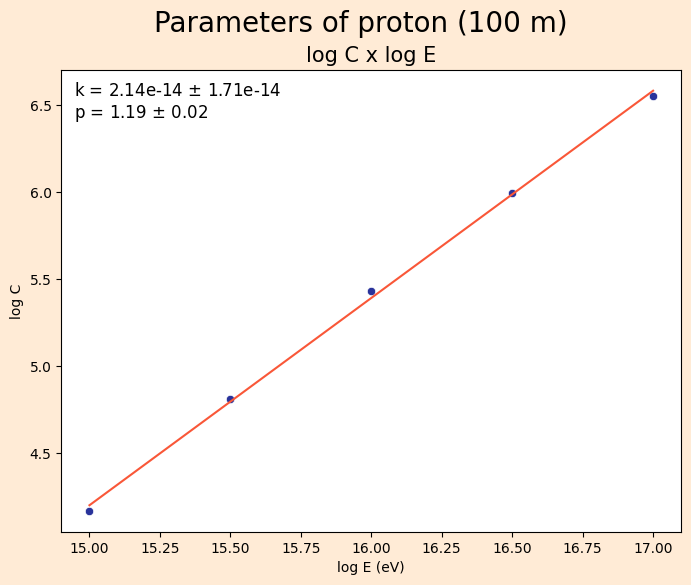

In [185]:
# Fit do próton

C = [1.481e+04, 6.475e+04, 2.698e+05, 9.954e+05, 3.595e+06]
E = [1E15, 3.16E15, 1E16, 3.16E16, 1E17]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of proton (100 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_proton, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_proton))

ax.plot(logE, power(E,*coefficients_proton), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#29339B', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_proton[0],inc[0],coefficients_proton[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_proton[0]))/coefficients_proton[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

In [186]:
k_photon = coefficients_proton[0] #- inc[0]
p_photon = coefficients_proton[1] #- inc[1]
c_photon = parameters_df['C'] #- parameters_df['C_err']

E_photon = []
E_real = float(name.split(' ')[1])

erro_relativo = []
erro_absoluto = []

for i in range(len(c_photon)):
    E = (c_photon[i] / k_photon) ** (1 / p_photon)
    E_photon.append(E)
    
    # Calcular erro absoluto
    erro_abs = abs(E - E_real)
    erro_absoluto.append(erro_abs)
    
    # Calcular erro relativo (em porcentagem)
    erro_rel = (erro_abs / E_real) * 100
    erro_relativo.append(erro_rel)

data = {
    'E':E_photon,
    'Relative_error':erro_relativo,
    'Absolute_error':erro_absoluto
}

df3 = pl.DataFrame(data)
df3

E,Relative_error,Absolute_error
f64,f64,f64
3.7628e16,62.372456,6.2372e16
2.2498e16,77.502141,7.7502e16
8.5902e15,91.409837,9.1410e16
2.2957e16,77.042786,7.7043e16
1.6735e16,83.264789,8.3265e16
…,…,…
1.1430e17,14.304556,1.4305e16
1.5632e17,56.317433,5.6317e16
6.7732e16,32.267998,3.2268e16


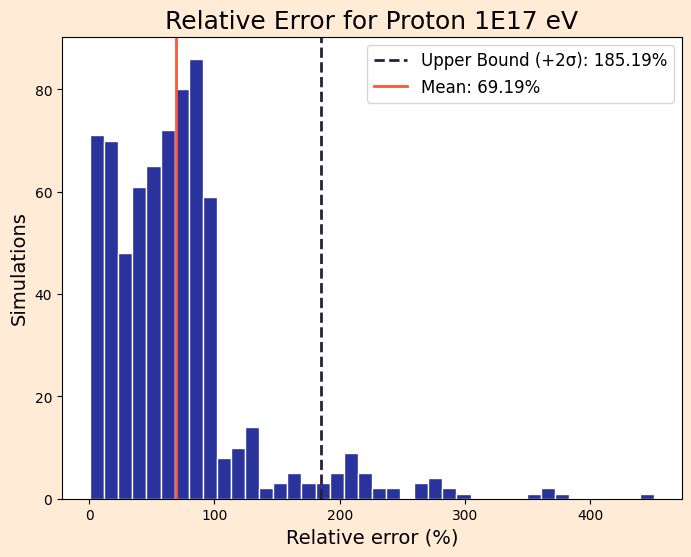

In [187]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.hist(erro_relativo, color='#29339B', bins= 40, edgecolor = 'white')
plt.ylabel('Simulations')
plt.xlabel('Relative Error (%)')
plt.title('Relative Error for ' + str(name) + ' eV', size = 18)
#plt.grid(True)

# Calcula a média e o desvio padrão dos dados
mean = df3['Relative_error'].mean()
std = df3['Relative_error'].std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std


# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2f}%')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2f}%')

# Personaliza o eixo e a legenda
ax.set_xlabel('Relative error (%)', size=14)
ax.set_ylabel('Simulations', size=14)
ax.legend(loc='upper right', fontsize=12)

plt.savefig('plots/' + name.split(' ')[0].lower() +'/energy_'+ caminho_arquivo.split('/')[-1] + '_array.png',bbox_inches = 'tight')

In [188]:
from uncertainties import ufloat
import uncertainties.umath as umath

k_value = coefficients_proton[0]
k_error = inc[0]  
p_value = coefficients_proton[1]
p_error = inc[1]  

k_proton = ufloat(k_value, k_error)
p_proton = ufloat(p_value, p_error)

c_protons = [ufloat(c, c_err) for c, c_err in zip(parameters_df['C'], parameters_df['C_err'])]

E_photon_with_errors = []

E_real = float(name.split(' ')[1])

for c in c_protons:
    E = (c / k_photon) ** (1 / p_photon)
    E_photon_with_errors.append(E)


E_nominal = [e.nominal_value for e in E_photon_with_errors]
E_error = [e.std_dev for e in E_photon_with_errors]

erro_absoluto = [abs(e.nominal_value - E_real) for e in E_photon_with_errors]
erro_relativo = [(erro / E_real) * 100 for erro in erro_absoluto]


data = {
    'E': E_nominal,
    'Propagated_uncertainty': E_error,
    'Absolute_error': erro_absoluto,
    'Relative_error': erro_relativo    
}

df3 = pl.DataFrame(data)

df3

E,Propagated_uncertainty,Absolute_error,Relative_error
f64,f64,f64,f64
3.7628e16,4.3075e15,6.2372e16,62.372456
2.2498e16,3.6728e15,7.7502e16,77.502141
8.5902e15,3.3125e15,9.1410e16,91.409837
2.2957e16,3.6237e15,7.7043e16,77.042786
1.6735e16,3.1945e15,8.3265e16,83.264789
…,…,…,…
1.1430e17,1.0752e16,1.4305e16,14.304556
1.5632e17,1.1129e16,5.6317e16,56.317433
6.7732e16,7.9352e15,3.2268e16,32.267998


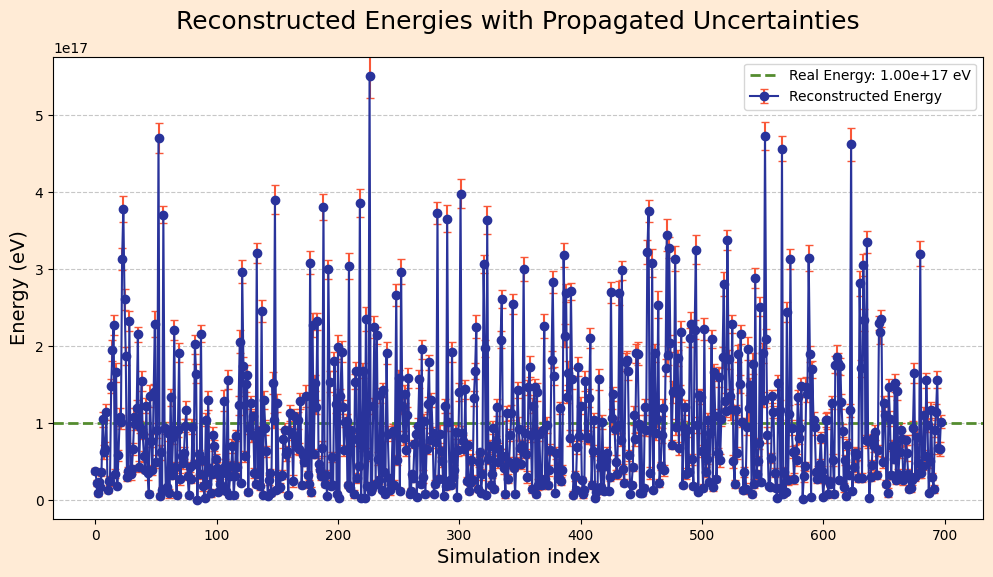

In [189]:
x = np.arange(len(E_nominal))  

plt.figure(figsize=(12, 6), facecolor='#FFEBD6')
ax = plt.gca()

plt.errorbar(
    x,
    E_nominal,
    yerr=E_error,
    fmt='-o',           
    color='#29339B',    
    ecolor='#F95738',   
    elinewidth=1.5,    
    capsize=3,          
    #alpha=0.7,          
    label='Reconstructed Energy'
)

plt.axhline(
    E_real,
    color='#548C2F',
    linestyle='--',
    linewidth=2,
    label=f'Real Energy: {E_real:.2e} eV'
)

plt.xlabel('Simulation index', size=14)
plt.ylabel('Energy (eV)', size=14)
plt.title('Reconstructed Energies with Propagated Uncertainties', size=18, pad=20)

# Adicionar legenda e grid
plt.legend(loc='upper right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.ylim(
    min(E_nominal) - 3 * np.mean(E_error),
    max(E_nominal) + 3 * np.mean(E_error)
)


plt.savefig('plots/' + name.split(' ')[0].lower() +'/energy_error_'+ caminho_arquivo.split('/')[-1] + '_array.png',bbox_inches = 'tight')